In [ ]:
'''code to sample/generate data from a certain PDF and save it as a file'''


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["savefig.bbox"]='tight'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

In [ ]:
r = np.random
r.seed(42)

In [ ]:

def sample_uniform_distribution(N_samples,min:float,max:float)->np.array:
    """sample from uniform distribution from xmin to xmax, returns np.Array"""

    return r.uniform(min, max,N_samples)




def sample_normal_distribution(N_samples, mean:float, sigma:float)->np.array:
    """sample from normal distribution with given mean and sigma, returns np.Array"""

    return r.normal(mean, sigma, N_samples)


    

def sample_func(x):
    """function to sample from, returns value of function at x"""

    try:
        y=x+2


    except ZeroDivisionError:
        print("ZeroDivisionError: x cannot be zero.")
        y=0
    except Exception as e:
        print(f"An error occurred: {e}")
        y=0
    return y




def sample_data_via_accept_reject(xmin:float=0, xmax:float=1, N_samples:int=10000)->np.array:
    """data generated with accept/reject method for given function within given boundaries, returns array of accepted x values"""


    #sample_func=samp_func
    x_accepted = np.zeros(N_samples)

    list_x = np.linspace(xmin, xmax, 1000)
    list_y = sample_func(list_x)
    ymax = np.max(list_y)*1.1
    print(f'Maximum of function: {ymax}')

    for i in range(N_samples):
        while True:
            x_rand = r.uniform(xmin, xmax)  
            y_rand = r.uniform(0, ymax)            
            if (y_rand < sample_func(x_rand)):
                break
                
        x_accepted[i] = x_rand
    return x_accepted

9.679347418027787


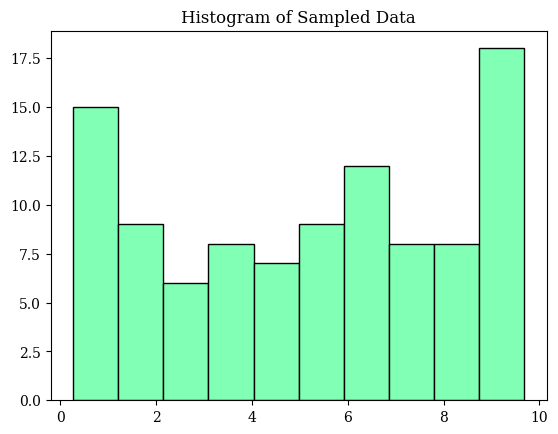

,x
0,8.982688
1,1.893493
2,3.181029
3,6.407307
4,1.096140
...,...
95,6.069625
96,0.897214
97,7.708022
98,7.684262


In [114]:

random_array=sample_uniform_distribution(N_samples=100, min=0, max=9.7)

print(random_array.max())

plt.hist(random_array, bins=10, density=False,color=my_cmap(0.5), edgecolor='black')

plt.title('Histogram of Sampled Data')
plt.show()



"""save to file"""

df = pd.DataFrame(random_array)
df.columns = ['x']

df.to_csv('sampled_uniform_data.csv', index=False,sep=',')
df

In [115]:
"""read from file"""
df = pd.read_csv('sampled_uniform_data.csv')
df

,x
0,8.982688
1,1.893493
2,3.181029
3,6.407307
4,1.096140
...,...
95,6.069625
96,0.897214
97,7.708022
98,7.684262


3.2789809681762363


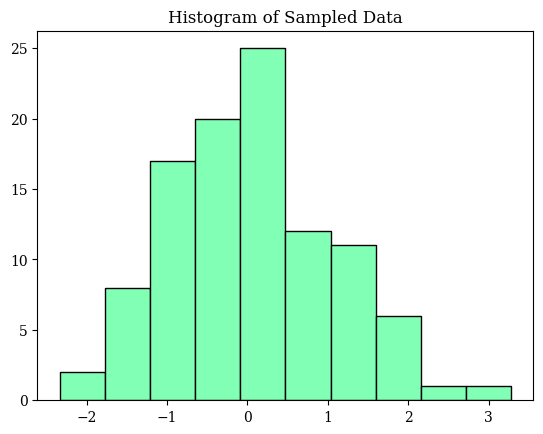

,x
0,0.462492
1,1.833530
2,-0.100179
3,-0.517142
4,3.278981
...,...
98,-0.080058
99,-0.829024
100,2.264216
101,-1.686811


In [116]:

random_array=sample_normal_distribution(N_samples=103, mean=0, sigma=np.sqrt(1.2))

print(random_array.max())

plt.hist(random_array, bins=10, density=False,color=my_cmap(0.5), edgecolor='black')

plt.title('Histogram of Sampled Data')
plt.show()



"""save to file"""

df = pd.DataFrame(random_array)
df.columns = ['x']

df.to_csv('sampled_normal_data.csv', index=False,sep=',')
df

In [108]:
"""save to file"""
mainarray=[random_array,random_array+2]
df = pd.DataFrame(mainarray).T
df.columns = ['x', 'y']
df
#df.to_csv('sampled_data.csv', index=False,sep=',')

,x,y
0,0.341299,2.341299
1,0.566832,2.566832
2,0.144360,2.144360
3,0.119733,2.119733
4,0.122260,2.122260
...,...,...
9995,0.110751,2.110751
9996,0.516656,2.516656
9997,0.535510,2.535510
9998,0.568280,2.568280
